# To Hedge, or Not To Hedge

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None) # Show all columns when printing a dataframe

## Prepare data

In [2]:
df = pd.read_excel('/home/jlaw/projects/python/roboAdvisorSystTrading/notebooks/data/alpha_strategy_plus_hedge_assignment_exercise.xlsx', header=2)
df = df.iloc[2:] # Remove rows where Hedge hasn't computed yet
df.head()

,Month,Alpha,Hedge
2,2009-10-01,-0.006457,-0.0042
3,2009-11-01,-0.006403,0.0160
4,2009-12-01,0.003051,-0.0205
5,2010-01-01,-0.010251,0.0350
6,2010-02-01,0.005158,-0.0246


In [3]:
df[['Alpha_cumulative_returns','Hedge_cumulative_returns']] = (1 + df[['Alpha','Hedge']]).cumprod() - 1
df.head()

,Month,Alpha,Hedge,Alpha_cumulative_returns,Hedge_cumulative_returns
2,2009-10-01,-0.006457,-0.0042,-0.006457,-0.004200
3,2009-11-01,-0.006403,0.0160,-0.012819,0.011733
4,2009-12-01,0.003051,-0.0205,-0.009806,-0.009008
5,2010-01-01,-0.010251,0.0350,-0.019957,0.025677
6,2010-02-01,0.005158,-0.0246,-0.014902,0.000445


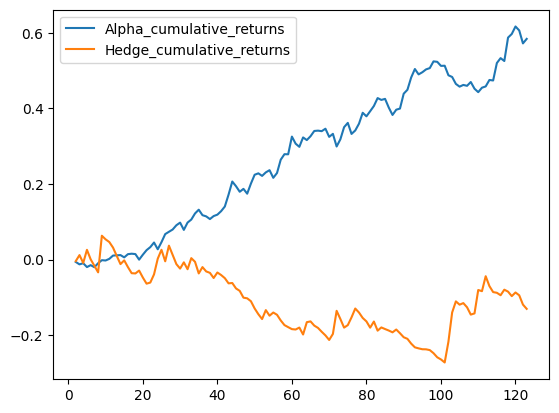

In [4]:
df.plot(y=['Alpha_cumulative_returns','Hedge_cumulative_returns']);

## Create hedged strategy

In [5]:
# Ratio of 1:1 to begin
df['strategy'] = 0.5*df['Alpha'] + 0.5*df['Hedge']
df['strategy_cumulative_returns'] = (1 + df['strategy']).cumprod() - 1
df.head()

,Month,Alpha,Hedge,Alpha_cumulative_returns,Hedge_cumulative_returns,strategy,strategy_cumulative_returns
2,2009-10-01,-0.006457,-0.0042,-0.006457,-0.004200,-0.005329,-0.005329
3,2009-11-01,-0.006403,0.0160,-0.012819,0.011733,0.004799,-0.000556
4,2009-12-01,0.003051,-0.0205,-0.009806,-0.009008,-0.008724,-0.009275
5,2010-01-01,-0.010251,0.0350,-0.019957,0.025677,0.012375,0.002985
6,2010-02-01,0.005158,-0.0246,-0.014902,0.000445,-0.009721,-0.006765


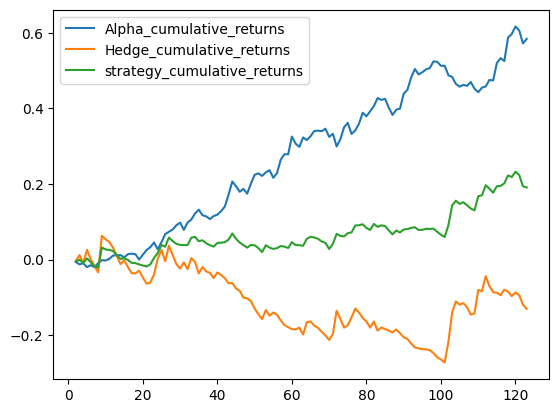

In [6]:
df.plot(y=['Alpha_cumulative_returns','Hedge_cumulative_returns','strategy_cumulative_returns']);

#### Hedged Strategy appears to have mediocre returns compared to Pure Alpha strategy

## Evaluate hedged strategy

In [7]:
# Sharpe ratio comparisons
print('Pure Alpha sharpe:',      ((df['Alpha'].mean() / df['Alpha'].std()) * np.sqrt(12)).round(2))
print('Hedged Strategy sharpe:', ((df['strategy'].mean() / df['strategy'].std()) * np.sqrt(12)).round(2))

Pure Alpha sharpe: 1.06
Hedged Strategy sharpe: 0.44


In [8]:
# Drawdown comparisons
df[['Alpha_cumulative_value','strategy_cumulative_value']] = 1 + df[['Alpha_cumulative_returns','strategy_cumulative_returns']]
df[['Alpha_drawdown','strategy_drawdown']] = df[['Alpha_cumulative_value','strategy_cumulative_value']] / df[['Alpha_cumulative_value','strategy_cumulative_value']].cummax() - 1

print('Pure Alpha drawdown:',int(df['Alpha_drawdown'].min()*100),'%')
print('Hedged Strategy drawdown:',int(df['strategy_drawdown'].min()*100),'%')

Pure Alpha drawdown: -5 %
Hedged Strategy drawdown: -4 %


### The pure Alpha approach has a much stronger Sharpe ratio (1 > 0.4) and comparable Drawdowns than the 50/50 Alpha-Hedge strategy
### Initially it seems the pure Alpha approach is better without the Hedge

## Consider different hedge weights

In [9]:
optimal_hedge_weight = 1000.0
strategy_max_sharpe = -1000.0
strategy_drawdown_at_max_sharpe = -1000.0

all_hedge_weights, all_sharpes, all_drawdowns = [], [], []

for weight in np.arange(-0.5, 0.5, 0.01):
    alpha_weight = 0.5 - weight
    hedge_weight = 0.5 + weight
    all_hedge_weights.append(hedge_weight)
    # print('alpha_weight',alpha_weight, 'hedge_weight',hedge_weight)
    
    df['strategy'] = (alpha_weight*df['Alpha']) + (hedge_weight*df['Hedge'])
    df['strategy_cumulative_returns'] = (1 + df['strategy']).cumprod() - 1

    strategy_sharpe = (df['strategy'].mean() / df['strategy'].std()) * np.sqrt(12)
    all_sharpes.append(strategy_sharpe)

    df['strategy_cumulative_value'] = 1 + df['strategy_cumulative_returns']
    df['strategy_drawdown'] = df['strategy_cumulative_value'] / df['strategy_cumulative_value'].cummax() - 1
    strategy_drawdown = df['strategy_drawdown'].min()
    all_drawdowns.append(strategy_drawdown)
    
    # print(weight, strategy_sharpe, strategy_drawdown)
    
    # If curr sharpe as good or better than we've seen
    if strategy_sharpe >= strategy_max_sharpe:
        strategy_max_sharpe = strategy_sharpe
        # And if at curr sharpe we have better drawdown than we've seen at prev best sharpe
        if strategy_drawdown > strategy_drawdown_at_max_sharpe:
            # Record this drawdown performance
            strategy_drawdown_at_max_sharpe = strategy_drawdown
            # And record this weight
            optimal_hedge_weight = hedge_weight
        # Otherwise for the same sharpe we've seen better drawdown, so don't update sharpe or optimal hedge weight

# Print optimal mix results
print('optimal_hedge_weight:',int(optimal_hedge_weight*100),'%')
print('strategy_max_sharpe:',strategy_max_sharpe.round(2))
print('strategy_drawdown_at_max_sharpe:',int(strategy_drawdown_at_max_sharpe*100),'%')

optimal_hedge_weight: 10 %
strategy_max_sharpe: 1.09
strategy_drawdown_at_max_sharpe: -2 %


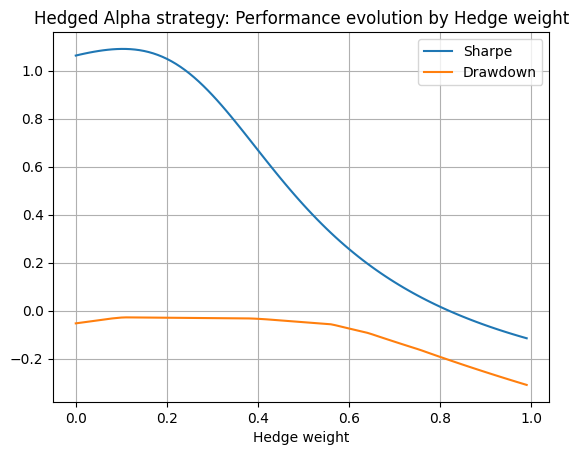

In [10]:
# Visualize evolution of performance by hedge weight
plt.plot(all_hedge_weights, all_sharpes, label='Sharpe')
plt.plot(all_hedge_weights, all_drawdowns, label='Drawdown')
plt.xlabel('Hedge weight')
plt.legend()
plt.grid(True)
plt.title('Hedged Alpha strategy: Performance evolution by Hedge weight')
plt.show()

### Results show that optimal Sharpe is achieved with a portfolio consisting of 90% Alpha strategy and 10% Hedge strategy
### Drawdown increases noticably as Hedge weight exceeds 50% of the portfolio, which makes intuitive sense
#### (since a Hedge is generally inverse-market, and the market tends to drift upward over time)

# My Decision: How I would construct a portfolio consisting of Alpha strategy and the Hedge
## Use 90/10 Alpha-Hedge ratio: improved Sharpe (1.1 > 1) and improved Drawdown (-2% > -5%) over Pure Alpha
## The 90/10 ratio also dramatically improves upon the initial 50/50 ratio Sharpe (1.1 > 0.4) and Drawdown (-2% > -4%)